In [46]:
from Environment import *
from DDPG import *
from NN_Module import *

import torch
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from numpy import linalg as LA

from loguru import logger

### a simple logger
logger.remove()
logger.add(sys.stderr, level='INFO')

9

In [47]:
a = [5,2,3]
print(LA.norm(a,2))

6.164414002968976


In [48]:
env_seed = 7        #10-h  5-h 0-l 1-h 2-l 3-l 4l 7h 8h 9l
episode_num = 200   # the total test episode
step_num = 200      # the longest test step

### create testing environment
injection_bus = np.array([18, 21, 30, 45, 53])-1
pp_net = create_56bus()
env = VoltageCtrl_Env(pp_net, injection_bus)
state, topology, senario = env.reset_topo(seed=env_seed)
topology = torch.cuda.FloatTensor(topology).unsqueeze(0)
# pf_res_plotly(pp_net);

### Some Plot Function

In [49]:
def moving_average(a, n=3):
    # Padding the array to maintain the length after convolution.
    pad = np.pad(a, (n//2, n-1-n//2), mode='edge')
    ret = np.convolve(pad, np.ones(n), mode='valid') / n
    return ret

# plot policy
def plot_policy(policy_net, topology):
    fig, axs = plt.subplots(1, 5, figsize=(15,3))
    title = ['Bus 18', 'Bus 21', 'Bus 30', 'Bus 45', 'Bus 53']
    for i in range(5):
        axs[i].clear()
        # plot policy
        N = 400
        s_array = np.zeros(N,)
        
        a_array_baseline = np.zeros(N,)
        a_array = np.zeros(N,)
        
        for j in range(N):
            state = torch.tensor([[0.80+0.001*j]])
            s_array[j] = state

            action_baseline = (np.maximum(state.cpu()-1.05, 0)-np.maximum(0.95-state.cpu(), 0)).reshape((1,))
        
            action = policy_net[i](state, topology)
            action = action.detach().cpu().numpy()[0]
            
            a_array_baseline[j] = -action_baseline[0]
            a_array[j] = -action

        a_array_s = moving_average(a_array, n=20)
        axs[i].plot(12*s_array, 5*a_array_baseline, '-.', label = 'Linear')
        axs[i].plot(12*s_array, a_array_s, label = 'Flexible-DDPG')
        axs[i].set_title(title[i])
        axs[i].legend(loc='lower left')

def plot_safe_net(net):
    fig, axs = plt.subplots(1, 5, figsize=(15,3))
    title = ['Bus 18', 'Bus 21', 'Bus 30', 'Bus 45', 'Bus 53']
    for i in range(agent_num):
        N = 400
        s_array = np.zeros(N,)
        
        a_array_baseline = np.zeros(N,)
        a_array = np.zeros(N,)
        
        for j in range(N):
            state = np.array([0.8+0.001*j])
            s_array[j] = state

            action_baseline = (np.maximum(state-1.05, 0)-np.maximum(0.95-state, 0)).reshape((1,))
        
            action = net[i].get_action([state])
            
            a_array_baseline[j] = -action_baseline[0]
            a_array[j] = -action

        axs[i].plot(12*s_array, 5*a_array_baseline, '-.', label = 'Linear')
        axs[i].plot(12*s_array, 5*a_array, label = 'Stable-DDPG')
        axs[i].legend(loc='lower left')

def plot_x_policy(policy_net, topology):
    fig, axs = plt.subplots()
    for i in range(5):
        # plot policy
        N = 40
        s_array = np.zeros(N,)
        
        a_array_baseline = np.zeros(N,)
        a_array = np.zeros(N,)
        #topology = torch.cuda.FloatTensor(env.topology_init * np.random.uniform(0.7,1.3)).unsqueeze(0)
        state, topology, senario = env.reset_topo(seed=i)
        topology = torch.cuda.FloatTensor(topology).unsqueeze(0)
        print(topology)
        
        for j in range(N):
            state = torch.tensor([[0.80+0.01*j]])
            s_array[j] = state

            action_baseline = (np.maximum(state.cpu()-1.05, 0)-np.maximum(0.95-state.cpu(), 0)).reshape((1,))
        
            action = policy_net[2](state, topology)
            action = action.detach().cpu().numpy()[0]
            
            a_array_baseline[j] = -action_baseline[0]
            a_array[j] = -action

        axs.plot(12*s_array, a_array_baseline, '-.', label = 'Linear')
        axs.plot(12*s_array, a_array, label = 'Flexible-DDPG')
        axs.legend(loc='lower left')
        plt.pause(0.1)

### Load model

In [50]:
agent_num = 5
agent_policy_net = []
safe_agent_net = []

### load nn model parameter from saved model 
for i in range(agent_num):
    topology_net = TopologyNet(topology_dim=55, output_dim=1, hidden_dim=256)
    policy_net = FlexiblePolicyNet(env=env, topology_net=topology_net, obs_dim=1, action_dim=1, hidden_dim=2048).to(device)
    agent_policy_net.append(policy_net)

for i in range(agent_num):
    policy_net = SafePolicyNetwork(env=env, obs_dim=1, action_dim=1, hidden_dim=100).to(device)
    safe_agent_net.append(policy_net)

for i in range(agent_num):
    #value_net_dict = torch.load(f'check_points/value_net/2023-06-19/Step_200_Seed_12_a{i}.pth')
    #policy_net_dict = torch.load(f'check_points/policy_net/2023-07-05/Step_300_Seed_45_a{i}.pth')
    # policy_net_dict = torch.load(f'check_points/policy_net/2023-08-15/Step_900_Seed_33_a{i}.pth')
    policy_net_dict = torch.load(f'check_points/policy_net/2023-09-21/Step_900_Seed_10_a{i}.pth')
    agent_policy_net[i].load_state_dict(policy_net_dict)

for i in range(agent_num):
    #value_net_dict = torch.load(f'D:/Code/Python/StableRL_VoltageCtrl-main/saved_models/2023-06-19/SafeDDPG_value_Step_200_a{i}.pth')
    policy_net_dict = torch.load(f'D:/Code/Python/StableRL_VoltageCtrl-main/saved_models/stable_ddpg/policy_net_checkpoint_a{i}.pth')
    safe_agent_net[i].load_state_dict(policy_net_dict)

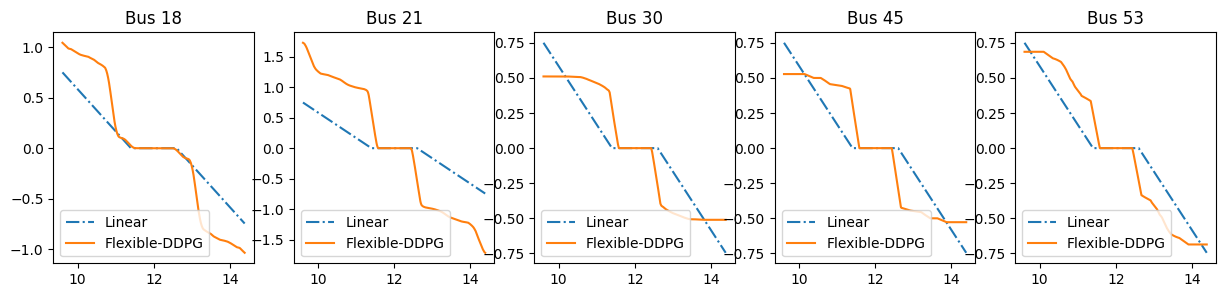

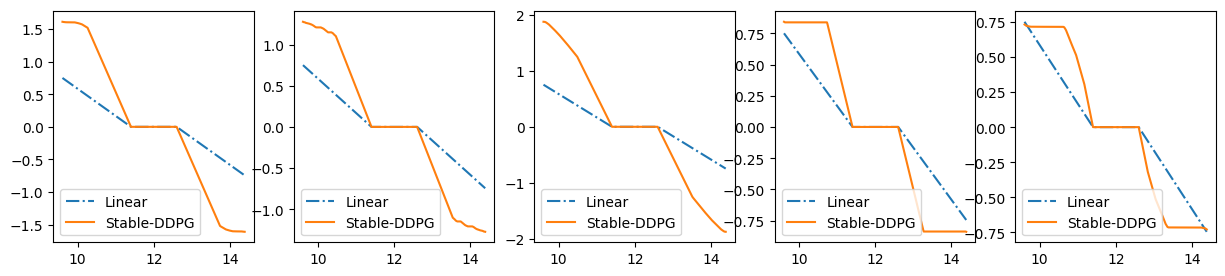

In [51]:
plot_policy(agent_policy_net, topology)
plot_safe_net(safe_agent_net)

### Flexible NN Contoller

In [52]:
### test our controller
voltage = []
q = []
cost = []
success_list = []
fail_list = []
entire_list = []
control_cost = []
reward_list = []
object_cost = []

for episode in range(episode_num):
    state, topology, senario = env.reset_topo(seed=episode)
    topology = torch.cuda.FloatTensor(topology).unsqueeze(0)
    last_action = np.zeros((agent_num,1))
    episode_reward = 0
    episode_control = 0
    cost = []
    abnormal_stop = False

    for step in range(step_num):
        action = []
        for i in range(agent_num):
            action_agent = agent_policy_net[i](torch.cuda.FloatTensor(state[i].reshape(1,)).unsqueeze(0), topology)
            action_agent = action_agent.detach().cpu().numpy()[0]
            action.append(action_agent)

        action = last_action - np.asarray(action)
        
        last_action = np.copy(action)
        
        try:
            next_state, reward, done = env.step(action)
        except pp.powerflow.LoadflowNotConverged:
            # logger.error(sys.exc_info())
            logger.error('power flow not converge at epsisode{} step{}', episode, step)
            fail_list.append((episode,step))
            abnormal_stop = True
            break

        if(np.min(next_state) < 0.75 or np.max(next_state) > 1.25): #if voltage violation > 25%, episode ends.
            logger.warning('episode {} step {} exceeds, min_state is {}, max_state is {}', episode, step, np.min(next_state), np.max(next_state))
            fail_list.append((episode,step))
            abnormal_stop = True
            break
        if done:
            success_list.append((episode,step))
            logger.success('episode {} stable at {} steps',success_list[-1][0], success_list[-1][1])
            break

        voltage.append(state)

        q.append(action)

        state = next_state
        
        episode_reward += reward
        
        cost.append(-reward)
        
        episode_control += LA.norm(action, 2)

    reward_list.append(episode_reward)
    control_cost.append(episode_control)
    object_cost.append(np.sum(cost))

    if (not done) and (abnormal_stop == False):
        entire_list.append(episode)
        logger.info('Episode {} finish with entire step!', episode)

logger.info('total success epsisode is {}', len(success_list))
logger.info('total fail episode is {}', len(fail_list))
logger.info('number of finished at entire episode is {}', len(entire_list))

2023-09-21 10:56:24.654 | SUCCESS  | __main__:<module>:48 - episode 0 stable at 15 steps
2023-09-21 10:56:24.857 | SUCCESS  | __main__:<module>:48 - episode 1 stable at 4 steps
2023-09-21 10:56:25.751 | SUCCESS  | __main__:<module>:48 - episode 2 stable at 24 steps
2023-09-21 10:56:27.156 | SUCCESS  | __main__:<module>:48 - episode 3 stable at 40 steps
2023-09-21 10:56:27.223 | SUCCESS  | __main__:<module>:48 - episode 4 stable at 1 steps
2023-09-21 10:56:28.201 | SUCCESS  | __main__:<module>:48 - episode 5 stable at 35 steps
2023-09-21 10:56:28.247 | SUCCESS  | __main__:<module>:48 - episode 6 stable at 0 steps
2023-09-21 10:56:28.578 | SUCCESS  | __main__:<module>:48 - episode 7 stable at 11 steps
2023-09-21 10:56:28.728 | SUCCESS  | __main__:<module>:48 - episode 8 stable at 4 steps
2023-09-21 10:56:29.126 | SUCCESS  | __main__:<module>:48 - episode 9 stable at 14 steps
2023-09-21 10:56:29.598 | SUCCESS  | __main__:<module>:48 - episode 10 stable at 16 steps
2023-09-21 10:56:30.369 

In [62]:
success_list = np.array(success_list)
print('average recovery step is:')
print(np.mean(success_list[:,1]))
print(np.std(success_list[:,1]))
print('average reactive power cost is:')
print(np.mean(control_cost))
print(np.std(control_cost))
print('the total cost is:')
print(object_cost)
print(np.mean(object_cost))
print(np.std(object_cost))


average recovery step is:
9.725
9.195073409168629
average reactive power cost is:
31.226176600950065
40.286001944781084
the total cost is:
[8.162639816661805, 1.2116804805944494, 13.072022991473148, 12.403917831291118, 1.7230134110806727, 29.401213465587908, 0.0, 14.242909493479873, 4.732512895749645, 2.91845828553494, 9.859583256570499, 14.495739645522752, 7.146478953032189, 4.7158849428106775, 1.5866549269026224, 0.0, 0.9297812511234007, 10.122373580415253, 6.7877547495486725, 4.155542066770319, 0.0, 1.2977301818892992, 2.339194257981382, 1.8487985373810785, 1.3459104827042334, 1.8620590732790872, 0.7351213077082589, 8.723344044750439, 7.619528471411581, 0.0, 0.0, 10.198562762567805, 13.427506983012622, 2.016832240632768, 6.583441717764288, 8.017670098424398, 16.724518965548032, 12.635208634628263, 0.316787423591731, 32.18511641608217, 0.9855945895638404, 1.6453552819658324, 1.3492703551080671, 0.0, 0.0, 10.076700473900843, 7.169686605468867, 0.39609784941470405, 4.572371210226002, 4

In [54]:
### test our controller without topology change
voltage_ = []
q_ = []
cost_ = []
success_list_ = []
fail_list_ = []
entire_list_ = []
control_cost_ = []
reward_list_ = []
object_cost_list_ = []

for episode in range(episode_num):
    state, topology, senario = env.reset_topo(seed=episode)
    topology = 1/env.topology_init
    topology = torch.cuda.FloatTensor(topology).unsqueeze(0)
    last_action = np.zeros((agent_num,1))
    episode_reward = 0
    episode_control = 0
    cost_ = []
    abnormal_stop = False

    for step in range(step_num):
        action = []
        for i in range(agent_num):
            action_agent = agent_policy_net[i](torch.cuda.FloatTensor(state[i].reshape(1,)).unsqueeze(0), topology)
            action_agent = action_agent.detach().cpu().numpy()[0]
            action.append(action_agent)

        action = last_action - np.asarray(action)
        
        last_action = np.copy(action)
        
        try:
            next_state, reward, done = env.step(action)
        except pp.powerflow.LoadflowNotConverged:
            # logger.error(sys.exc_info())
            logger.error('power flow not converge at epsisode{} step{}', episode, step)
            fail_list_.append((episode,step))
            abnormal_stop = True
            break

        if(np.min(next_state) < 0.75 or np.max(next_state) > 1.25): #if voltage_ violation > 25%, episode ends.
            logger.warning('episode {} step {} exceeds, min_state is {}, max_state is {}', episode, step, np.min(next_state), np.max(next_state))
            fail_list_.append((episode,step))
            abnormal_stop = True
            break
        if done:
            success_list_.append((episode,step))
            logger.success('stable at {}',success_list_[-1])
            break

        voltage_.append(state)

        q_.append(action)

        state = next_state
        
        episode_reward += reward
        
        cost_.append(-reward)
        
        episode_control += LA.norm(action, 2)

    reward_list_.append(episode_reward)
    control_cost_.append(episode_control)
    object_cost_list_.append(np.sum(cost_))

    if (not done) and (abnormal_stop == False):
        entire_list_.append(episode)
        logger.info('Episode {} finish with entire step!', episode)

logger.info('total success epsisode is {}', len(success_list_))
logger.info('total fail episode is {}', len(fail_list_))
logger.info('number of finished at entire episode is {}', len(entire_list_))

2023-09-21 10:57:39.041 | SUCCESS  | __main__:<module>:49 - stable at (0, 13)
2023-09-21 10:57:39.376 | SUCCESS  | __main__:<module>:49 - stable at (1, 8)
2023-09-21 10:57:40.404 | SUCCESS  | __main__:<module>:49 - stable at (2, 28)
2023-09-21 10:57:41.844 | SUCCESS  | __main__:<module>:49 - stable at (3, 38)
2023-09-21 10:57:41.930 | SUCCESS  | __main__:<module>:49 - stable at (4, 1)
2023-09-21 10:57:43.060 | SUCCESS  | __main__:<module>:49 - stable at (5, 30)
2023-09-21 10:57:43.113 | SUCCESS  | __main__:<module>:49 - stable at (6, 0)
2023-09-21 10:57:43.574 | SUCCESS  | __main__:<module>:49 - stable at (7, 10)
2023-09-21 10:57:43.802 | SUCCESS  | __main__:<module>:49 - stable at (8, 5)
2023-09-21 10:57:44.472 | SUCCESS  | __main__:<module>:49 - stable at (9, 17)
2023-09-21 10:57:45.184 | SUCCESS  | __main__:<module>:49 - stable at (10, 15)
2023-09-21 10:57:46.530 | SUCCESS  | __main__:<module>:49 - stable at (11, 32)
2023-09-21 10:57:47.403 | SUCCESS  | __main__:<module>:49 - stable

In [61]:
success_list_ = np.array(success_list_)
print('average recovery step is:')
print(np.mean(success_list_[:,1]))
print(np.std(success_list_[:,1]))
print('average reactive power cost is:')
print(np.mean(control_cost_))
print(np.std(control_cost_))
print('the total cost is:')
print(np.mean(object_cost_list_))
print(np.std(object_cost_list_))

average recovery step is:
10.165
8.967595831659677
average reactive power cost is:
32.62663602244619
39.494222712069394
the total cost is:
5.250875572740841
5.262600403658743


### baseline

In [56]:
### test the base line controller
num_agent = 5
voltage = []
q = []
base_cost = []
base_succ_list = []
base_fail_list = []
base_entire_list = []
base_control_cost = []
base_reward_list = []
base_object_cost = []

for episode in range(episode_num):
    state, topology, senario = env.reset_topo(seed=episode)
    topology = torch.cuda.FloatTensor(topology).unsqueeze(0)
    last_action = np.zeros((agent_num,1))
    episode_reward = 0
    episode_control = 0
    base_cost = []
    abnormal_stop = False

    for step in range(step_num):
        state1 = np.asarray(state-env.vmax)
        state2 = np.asarray(env.vmin-state)
        d_v = (np.maximum(state1, 0)-np.maximum(state2, 0)).reshape((num_agent,1))
        
        action = (last_action - 10*d_v)
        
        last_action = np.copy(action)
        
        try:
            next_state, reward, done = env.step(action)
        except pp.powerflow.LoadflowNotConverged:
            # logger.error(sys.exc_info())
            logger.error('power flow not converge at epsisode{} step{}', episode, step)
            base_fail_list.append((episode,step))
            abnormal_stop = True
            break

        if(np.min(next_state) < 0.75 or np.max(next_state) > 1.25): #if voltage violation > 25%, episode ends.
            logger.warning('episode {} step {} exceeds, min_state is {}, max_state is {}', episode, step, np.min(next_state), np.max(next_state))
            base_fail_list.append((episode,step))
            abnormal_stop = True
            break
        if done:
            base_succ_list.append((episode,step))
            logger.success('stable at {}',base_succ_list[-1])
            break

        voltage.append(state)

        q.append(action)

        state = next_state
        
        episode_reward += reward
        
        base_cost.append(-reward)
        
        episode_control += LA.norm(action, 2)

    base_control_cost.append(episode_control)
    base_reward_list.append(episode_reward)
    base_object_cost.append(np.sum(base_cost))
    
    if (not done) and (abnormal_stop == False):
        base_entire_list.append(episode)
        logger.info('Episode {} finish with entire step!', episode)

logger.info('total success epsisode is {}', len(base_succ_list))
logger.info('total fail episode is {}', len(base_fail_list))
logger.info('number of finished at entire episode is {}', len(base_entire_list))

2023-09-21 10:59:04.983 | SUCCESS  | __main__:<module>:47 - stable at (0, 49)
2023-09-21 10:59:05.171 | SUCCESS  | __main__:<module>:47 - stable at (1, 11)
2023-09-21 10:59:06.296 | SUCCESS  | __main__:<module>:47 - stable at (2, 77)
2023-09-21 10:59:06.844 | SUCCESS  | __main__:<module>:47 - stable at (3, 39)
2023-09-21 10:59:07.408 | SUCCESS  | __main__:<module>:47 - stable at (4, 39)
2023-09-21 10:59:08.710 | SUCCESS  | __main__:<module>:47 - stable at (5, 94)
2023-09-21 10:59:08.825 | SUCCESS  | __main__:<module>:47 - stable at (6, 6)
2023-09-21 10:59:10.111 | SUCCESS  | __main__:<module>:47 - stable at (7, 91)
2023-09-21 10:59:11.753 | SUCCESS  | __main__:<module>:47 - stable at (8, 119)
2023-09-21 10:59:12.056 | SUCCESS  | __main__:<module>:47 - stable at (9, 19)
2023-09-21 10:59:13.115 | SUCCESS  | __main__:<module>:47 - stable at (10, 74)
2023-09-21 10:59:13.591 | SUCCESS  | __main__:<module>:47 - stable at (11, 32)
2023-09-21 10:59:13.874 | SUCCESS  | __main__:<module>:47 - st

In [60]:
base_succ_list = np.array(base_succ_list)
print('average recovery step is:')
print(np.mean(base_succ_list[:,1]))
print(np.std(base_succ_list[:,1]))
print('average reactive power cost is:')
print(np.mean(base_control_cost))
print(np.std(base_control_cost))
print('the total cost is:')
print(base_object_cost)
print(np.mean(base_object_cost))
print(np.std(base_object_cost))


average recovery step is:
38.695
30.62828717052261
average reactive power cost is:
172.16185555040985
289.74935344521197
the total cost is:
[17.951552114097552, 2.7940134044796894, 32.67557283147975, 11.606529409211719, 10.746218210626518, 62.685946100857485, 1.3396281556253045, 110.92039037895431, 78.87673296067382, 3.33327132897961, 33.62640037136934, 16.42918004285253, 7.645746486567438, 19.14717339709682, 2.3291600520760194, 2.9400829726163833, 18.244815856265934, 111.54855724881439, 5.915687084845027, 41.199924714307926, 0.0, 2.828815521404011, 2.667757492109416, 19.34335699085643, 6.520177876654102, 1.4503938444190865, 14.117538664343678, 15.435996955631886, 5.729569741173536, 9.990874098345243, 0.2245305648784866, 8.127136559190722, 51.880476552110544, 16.51480502655896, 44.57820397309248, 6.687528723223279, 140.48005699184563, 113.6298585233937, 0.26569925812242934, 77.43962989305483, 7.968519849467846, 3.4358520011407947, 9.315613506271749, 0.9998011103962839, 6.50947605509442

### Safe DDPG

In [58]:
### test the safe policy net
num_agent = 5
safe_voltage = []
safe_q = []
safe_cost = []
safe_succ_list = []
safe_fail_list = []
safe_entire_list = []
safe_contorl_cost = []
safe_reward_list = []
safe_object_cost = []

for episode in range(episode_num):
    state, topology, senario = env.reset_topo(seed=episode)
    topology = torch.cuda.FloatTensor(topology).unsqueeze(0)
    last_action = np.zeros((agent_num,1))
    episode_reward = 0
    episode_control = 0
    safe_cost = []
    abnormal_stop = False

    for step in range(step_num):
        action = []
        for i in range(num_agent):
            action_agent = safe_agent_net[i].get_action(torch.cuda.FloatTensor([state[i]]).float().reshape(1,1))
            action.append(action_agent)
        
        action = last_action - 5*np.asarray(action).reshape((num_agent, 1))
        
        last_action = np.copy(action)
        
        try:
            next_state, reward, done = env.step(action)
        except pp.powerflow.LoadflowNotConverged:
            # logger.error(sys.exc_info())
            logger.error('power flow not converge at epsisode{} step{}', episode, step)
            safe_fail_list.append((episode,step))
            abnormal_stop = True
            break

        if(np.min(next_state) < 0.75 or np.max(next_state) > 1.25): #if voltage violation > 25%, episode ends.
            logger.warning('episode {} step {} exceeds, min_state is {}, max_state is {}', episode, step, np.min(next_state), np.max(next_state))
            safe_fail_list.append((episode,step))
            abnormal_stop = True
            break
        if done:
            safe_succ_list.append((episode,step))
            logger.success('stable at {}',safe_succ_list[-1])
            break
        safe_voltage.append(state)

        safe_q.append(action)

        state = next_state
        
        episode_reward += reward
        
        safe_cost.append(-reward)
        
        episode_control += LA.norm(action, 2)

    safe_contorl_cost.append(episode_control)
    safe_reward_list.append(episode_reward)
    safe_object_cost.append(np.sum(safe_cost))

    if (not done) and (abnormal_stop == False):
        safe_entire_list.append(episode)
        logger.info('Episode {} finish with entire step!', episode)

logger.info('total success epsisode is {}', len(safe_succ_list))
logger.info('total fail episode is {}', len(safe_fail_list))
logger.info('number of finished at entire episode is {}', len(safe_entire_list))


2023-09-21 11:00:56.979 | SUCCESS  | __main__:<module>:48 - stable at (0, 32)
2023-09-21 11:00:57.174 | SUCCESS  | __main__:<module>:48 - stable at (1, 5)
2023-09-21 11:00:58.408 | SUCCESS  | __main__:<module>:48 - stable at (2, 53)
2023-09-21 11:00:58.977 | SUCCESS  | __main__:<module>:48 - stable at (3, 23)
2023-09-21 11:00:59.553 | SUCCESS  | __main__:<module>:48 - stable at (4, 21)
2023-09-21 11:01:01.243 | SUCCESS  | __main__:<module>:48 - stable at (5, 66)
2023-09-21 11:01:01.294 | SUCCESS  | __main__:<module>:48 - stable at (6, 0)
2023-09-21 11:01:02.975 | SUCCESS  | __main__:<module>:48 - stable at (7, 63)
2023-09-21 11:01:05.140 | SUCCESS  | __main__:<module>:48 - stable at (8, 83)
2023-09-21 11:01:05.452 | SUCCESS  | __main__:<module>:48 - stable at (9, 10)
2023-09-21 11:01:06.698 | SUCCESS  | __main__:<module>:48 - stable at (10, 51)
2023-09-21 11:01:07.204 | SUCCESS  | __main__:<module>:48 - stable at (11, 18)
2023-09-21 11:01:07.484 | SUCCESS  | __main__:<module>:48 - stab

In [59]:
safe_succ_list = np.array(safe_succ_list)
print('average recovery step is:')
print(np.mean(safe_succ_list[:,1]))
print(np.std(safe_succ_list[:,1]))
print('average reactive power cost is:')
print(np.mean(safe_contorl_cost))
print(np.std(safe_contorl_cost))
print('the total cost is:')
print(safe_object_cost)
print(np.mean(safe_object_cost))
print(np.std(safe_object_cost))

average recovery step is:
23.745
22.76510432657843
average reactive power cost is:
113.28480666367739
201.52561556901605
the total cost is:
[12.18768607820638, 1.5197491355052977, 22.51932226754655, 6.994906899685452, 6.263532770276684, 43.993417240263106, 0.0, 75.69881941191284, 55.19919878020849, 1.9696427362944475, 23.080244273236296, 9.619705454512243, 4.344151243529936, 13.112802765012711, 1.2688067241773597, 0.0, 12.537886477372536, 76.90471269717231, 3.516220383955166, 27.652189889536835, 0.0, 1.538520555934653, 1.5248106576091847, 11.445072108930734, 3.69884225491439, 0.8628661378353025, 8.777630169033213, 5.6362296130187595, 3.4665095960921932, 6.462864323507606, 0.0, 5.032466583309875, 36.26378335008545, 11.233736688717496, 30.448021015108104, 3.896610629562502, 97.94595109522152, 79.17463952577023, 0.14735582655604168, 53.97813603263481, 4.41312930787635, 0.0, 4.689264168760967, 0.0, 4.123121979302555, 16.970590765570506, 53.621618933879034, 0.21555894249692445, 8.1685178340